<a href="https://colab.research.google.com/github/Muhfaden/ailsi-tasi/blob/main/AILSI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AILSI - AI Liquidity Stress Index for the Saudi Equity Market (TASI)

### The idea

Global financial-conditions indices (Chicago Fed NFCI, OFR FSI, the bank FCIs) ignore the Saudi
market, while local quant work usually stops at price forecasting. Yet because the riyal is **pegged
to the US dollar** (SAR 3.75 since 1986), SAMA effectively imports US monetary policy - so Fed
tightening, a stronger dollar, and widening global credit spreads transmit into Saudi funding
conditions almost mechanically. Add oil-fiscal dynamics and post-2019 foreign-flow sensitivity, and
TASI becomes a market whose stress is heavily **imported** yet unmonitored by any purpose-built,
transparent, liquidity-aware gauge. **AILSI fills that gap.**

> This is **not** a price predictor. AILSI converts many signals into one 0–100 stress score,
> forecasts it, explains its drivers, and quantifies the downside risk to a hypothetical \$1M position.

In [1]:
%cd /content/drive/MyDrive/AILSI_Project

/content/drive/MyDrive/AILSI_Project


In [2]:
# === Portable setup =========================================================
# Idempotent: installs missing packages, then imports what Step 1 needs.
# ============================================================================
import importlib.util, subprocess, sys
from pathlib import Path

def _ensure(*pkgs):
    """pip-install any package that isn't importable yet (pip name -> import name handled)."""
    name = {"scikit-learn": "sklearn", "pyarrow": "pyarrow"}
    missing = [p for p in pkgs if importlib.util.find_spec(name.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

_ensure("pandas", "numpy", "matplotlib", "pyarrow", "yfinance")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# yfinance occasionally can't reach the network; import defensively so we can still fall back.
try:
    import yfinance as yf
except Exception:
    yf = None
    print("yfinance not importable — will use cache/synthetic for market data.")

np.random.seed(42)
RANDOM_STATE = 42
%matplotlib inline

# --- Find the repo root (folder holding README.md / requirements.txt), else cwd ---
def _find_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "README.md").exists() or (base / "requirements.txt").exists():
            return base
    return Path.cwd()

ROOT           = _find_root()
DATA_RAW       = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
ARTEFACT_DIR   = ROOT / "artefacts"
for d in (DATA_RAW, DATA_PROCESSED, ARTEFACT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Analysis window: 2010 -> today. Long enough for monthly ML, spans multiple stress regimes.
START = "2010-01-01"
END   = pd.Timestamp.today().normalize().strftime("%Y-%m-%d")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)

print(f"pandas    {pd.__version__}")
print(f"yfinance  {yf.__version__ if yf else 'not installed'}")
print(f"root      {ROOT}")
print(f"raw cache {DATA_RAW}")
print(f"window    {START} -> {END}")

pandas    2.2.2
yfinance  0.2.66
root      /content/drive/MyDrive/AILSI_Project
raw cache /content/drive/MyDrive/AILSI_Project/data/raw
window    2010-01-01 -> 2026-06-28


In [3]:
# FRED series: (id, label, block, freq, stress_sign, release_lag_months)
FRED_CATALOGUE = [
    # Oil & external (Saudi is oil- and USD-exposed)
    ("DCOILBRENTEU", "Brent crude oil (USD/bbl)",    "Oil & external",      "D", -1, 0),
    ("DCOILWTICO",   "WTI crude oil (USD/bbl)",      "Oil & external",      "D", -1, 0),
    ("DTWEXBGS",     "USD broad index",              "Oil & external",      "D", +1, 0),
    # Market stress
    ("VIXCLS",       "CBOE VIX (US implied vol)",    "Market stress",       "D", +1, 0),
    # Funding & credit (stress often shows here first) — BAA10Y has full 2010+ history
    ("BAA10Y",       "Moody's Baa - 10Y Treasury spread", "Funding & credit","D", +1, 0),
    # Rates & curve / policy (the peg channel)
    ("DGS10",        "10Y Treasury yield",           "Rates & curve",       "D", +1, 0),
    ("DGS2",         "2Y Treasury yield",            "Rates & curve",       "D", +1, 0),
    ("T10Y2Y",       "10Y-2Y term spread",           "Rates & curve",       "D", -1, 0),
    ("DFF",          "Effective Fed Funds (daily)",  "Rates & policy (peg)","D", +1, 0),
    ("FEDFUNDS",     "Fed Funds rate (monthly)",     "Rates & policy (peg)","M", +1, 1),
    # Money & liquidity
    ("M2SL",         "US M2 money stock",            "Money & liquidity",   "M", -1, 1),
    # Inflation
    ("CPIAUCSL",     "US CPI (all items, SA)",       "Inflation",           "M", +1, 1),
]

# Market series from Yahoo Finance: (ticker, label)
TICKER_CATALOGUE = [
    ("^TASI.SR","Tadawul All Share Index"),   # the market we monitor (Sun-Thu week)
    ("2222.SR", "Saudi Aramco"),              # oil-linked liquidity texture
    ("1180.SR", "Al Rajhi Bank"),             # non-oil contrast
]

catalogue = pd.DataFrame(
    [{"series_id": i, "label": l, "block": b, "freq": f,
      "stress_sign": s, "release_lag_m": r, "source": "FRED"}
     for (i, l, b, f, s, r) in FRED_CATALOGUE]
    + [{"series_id": t, "label": l, "block": "Saudi market", "freq": "D",
        "stress_sign": np.nan, "release_lag_m": 0, "source": "yfinance"}
       for (t, l) in TICKER_CATALOGUE]
)
print(f"{len(catalogue)} series across {catalogue['block'].nunique()} blocks\n")
catalogue

15 series across 8 blocks



,series_id,label,block,freq,stress_sign,release_lag_m,source
0,DCOILBRENTEU,Brent crude oil (USD/bbl),Oil & external,D,-1.0,0,FRED
1,DCOILWTICO,WTI crude oil (USD/bbl),Oil & external,D,-1.0,0,FRED
2,DTWEXBGS,USD broad index,Oil & external,D,1.0,0,FRED
3,VIXCLS,CBOE VIX (US implied vol),Market stress,D,1.0,0,FRED
4,BAA10Y,Moody's Baa - 10Y Treasury spread,Funding & credit,D,1.0,0,FRED
5,DGS10,10Y Treasury yield,Rates & curve,D,1.0,0,FRED
6,DGS2,2Y Treasury yield,Rates & curve,D,1.0,0,FRED
7,T10Y2Y,10Y-2Y term spread,Rates & curve,D,-1.0,0,FRED
8,DFF,Effective Fed Funds (daily),Rates & policy (peg),D,1.0,0,FRED
9,FEDFUNDS,Fed Funds rate (monthly),Rates & policy (peg),M,1.0,1,FRED


In [4]:
DATA_SOURCE = {}   # series_id -> "live" | "cache" | "synthetic"

# ---- synthetic fallback (offline/CI only; never used when the network is up) ----
def _synth_index(freq):
    if freq == "M":
        return pd.date_range(START, END, freq="MS")
    return pd.bdate_range(START, END)

def _synth_fred(series_id, freq):
    """Plausible-shaped stand-in. Shape only — NOT real data."""
    rng = np.random.default_rng(abs(hash(series_id)) % (2**32))
    idx = _synth_index(freq); n = len(idx)
    sid = series_id.upper()
    if "OIL" in sid or "BRENT" in sid or "WTI" in sid:           # oil: GBM-ish
        x = 70 * np.exp(np.cumsum(rng.normal(0, 0.02, n))); x = np.clip(x, 15, 140)
    elif sid == "VIXCLS":                                        # vol: mean-reverting + spikes
        x = 18 + np.cumsum(rng.normal(0, 0.8, n)); x = np.clip(np.abs(x), 9, 80)
    elif "OAS" in sid or sid.startswith("BAML"):                 # credit spread
        base = 4.0 if "H0A0" in sid else 1.4
        x = np.clip(base + np.cumsum(rng.normal(0, 0.03, n)), 0.4, 15)
    elif sid in ("DGS10", "DGS2", "DFF", "FEDFUNDS"):            # rates
        x = np.clip(2.5 + np.cumsum(rng.normal(0, 0.02, n)), 0.0, 8)
    elif sid == "T10Y2Y":                                        # term spread (can be negative)
        x = np.clip(1.0 + np.cumsum(rng.normal(0, 0.02, n)), -1.5, 3.0)
    elif sid == "DTWEXBGS":                                      # USD index
        x = 115 + np.cumsum(rng.normal(0, 0.1, n)); x = np.clip(x, 90, 135)
    elif sid == "M2SL":                                          # money stock: trend
        x = 9000 * np.exp(np.linspace(0, 0.9, n)) + rng.normal(0, 50, n)
    else:                                                        # CPI-like index: gentle uptrend
        x = 240 * np.exp(np.linspace(0, 0.35, n)) + rng.normal(0, 0.5, n)
    return pd.DataFrame({"date": idx, series_id.lower(): x})

def _synth_prices(ticker):
    rng = np.random.default_rng(abs(hash(ticker)) % (2**32))
    idx = pd.bdate_range(START, END); n = len(idx)
    close = 100 * np.exp(np.cumsum(rng.normal(0.0002, 0.013, n)))
    intraday = np.abs(rng.normal(0, 0.008, n))
    high = close * (1 + intraday); low = close * (1 - intraday)
    open_ = low + rng.random(n) * (high - low)
    vol = rng.integers(1_000_000, 8_000_000, n)
    df = pd.DataFrame({"open": open_, "high": high, "low": low, "close": close,
                       "adj_close": close, "volume": vol}, index=idx)
    df.index.name = "date"
    return df

# ---- live-first fetchers with cache + synthetic fallback ----
def fetch_fred(series_id, freq="D"):
    cache = DATA_RAW / f"fred_{series_id}.parquet"
    url = ("https://fred.stlouisfed.org/graph/fredgraph.csv"
           f"?id={series_id}&cosd={START}&coed={END}")
    try:
        raw = pd.read_csv(url, parse_dates=["observation_date"])
        raw.columns = ["date", series_id.lower()]
        raw = raw[pd.to_numeric(raw[series_id.lower()], errors="coerce").notna()]
        raw[series_id.lower()] = raw[series_id.lower()].astype(float)
        raw.to_parquet(cache, index=False)
        DATA_SOURCE[series_id] = "live"
        return raw
    except Exception as exc:
        if cache.exists():
            DATA_SOURCE[series_id] = "cache"
            return pd.read_parquet(cache)
        DATA_SOURCE[series_id] = "synthetic"
        print(f"  ! {series_id}: live+cache failed ({type(exc).__name__}) -> SYNTHETIC")
        return _synth_fred(series_id, freq)

def fetch_prices(ticker):
    cache = DATA_RAW / f"px_{ticker.replace('^','').replace('.','_')}.parquet"
    if yf is not None:
        try:
            raw = yf.download(ticker, start=START, end=END, auto_adjust=False, progress=False)
            if raw.empty:
                raise RuntimeError("empty response")
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            raw.columns = [c.lower().replace(" ", "_") for c in raw.columns]
            raw.index.name = "date"
            raw.to_parquet(cache)
            DATA_SOURCE[ticker] = "live"
            return raw
        except Exception as exc:
            print(f"  ! {ticker}: yfinance failed ({type(exc).__name__})")
    if cache.exists():
        DATA_SOURCE[ticker] = "cache"
        return pd.read_parquet(cache)
    DATA_SOURCE[ticker] = "synthetic"
    print(f"  ! {ticker}: live+cache failed -> SYNTHETIC")
    return _synth_prices(ticker)

print("Fetch helpers ready.")

Fetch helpers ready.


## 1.3 · Pull the macro series (FRED)

In [5]:
fred_raw = {}
for sid, label, block, freq, sign, lag in FRED_CATALOGUE:
    df = fetch_fred(sid, freq=freq)
    fred_raw[sid] = df
    src = DATA_SOURCE[sid]
    print(f"  {sid:16s} {src:9s} rows={len(df):5d}  ({label})")

print(f"\nPulled {len(fred_raw)} FRED series.")

  DCOILBRENTEU     live      rows= 4166  (Brent crude oil (USD/bbl))
  DCOILWTICO       live      rows= 4130  (WTI crude oil (USD/bbl))
  DTWEXBGS         live      rows= 4099  (USD broad index)
  VIXCLS           live      rows= 4175  (CBOE VIX (US implied vol))
  BAA10Y           live      rows= 4117  (Moody's Baa - 10Y Treasury spread)
  DGS10            live      rows= 4122  (10Y Treasury yield)
  DGS2             live      rows= 4122  (2Y Treasury yield)
  T10Y2Y           live      rows= 4123  (10Y-2Y term spread)
  DFF              live      rows= 6020  (Effective Fed Funds (daily))
  FEDFUNDS         live      rows=  197  (Fed Funds rate (monthly))
  M2SL             live      rows=  197  (US M2 money stock)
  CPIAUCSL         live      rows=  196  (US CPI (all items, SA))

Pulled 12 FRED series.


## 1.4 · Pull the market series (Yahoo Finance)

`^TASI` is the market we monitor; Aramco (`2222.SR`) and Al Rajhi (`1180.SR`) give an oil-linked vs.
non-oil contrast we'll use for liquidity texture later.

In [6]:
mkt_raw = {}
for ticker, label in TICKER_CATALOGUE:
    df = fetch_prices(ticker)
    mkt_raw[ticker] = df
    src = DATA_SOURCE[ticker]
    rng_str = f"{df.index.min().date()} -> {df.index.max().date()}"
    print(f"  {ticker:9s} {src:9s} rows={len(df):5d}  {rng_str}  ({label})")

print(f"\nPulled {len(mkt_raw)} market series.")

  ^TASI.SR  live      rows= 3667  2010-01-04 -> 2026-06-25  (Tadawul All Share Index)
  2222.SR   live      rows= 1634  2019-12-11 -> 2026-06-25  (Saudi Aramco)
  1180.SR   live      rows= 2933  2014-11-12 -> 2026-06-25  (Al Rajhi Bank)

Pulled 3 market series.


In [7]:
def _summarise(name, s):
    s = s.dropna()
    if len(s) < 2:
        return dict(series=name, n=len(s), start=None, end=None, gap_days=None, missing=int(s.isna().sum()))
    gap = pd.Series(s.index).diff().median()
    return dict(series=name, n=len(s),
                start=s.index.min().date(), end=s.index.max().date(),
                gap_days=int(gap.days) if pd.notna(gap) else None)

rows = []
for sid, df in fred_raw.items():
    ser = df.set_index("date")[sid.lower()]
    r = _summarise(sid, ser); r["source"] = DATA_SOURCE[sid]
    r["block"] = catalogue.set_index("series_id").loc[sid, "block"]
    rows.append(r)
for ticker, df in mkt_raw.items():
    ser = df["adj_close"] if "adj_close" in df.columns else df["close"]
    r = _summarise(ticker, ser); r["source"] = DATA_SOURCE[ticker]
    r["block"] = "Saudi market"
    rows.append(r)

coverage = pd.DataFrame(rows)[["series","block","source","n","start","end","gap_days"]]
coverage

,series,block,source,n,start,end,gap_days
0,DCOILBRENTEU,Oil & external,live,4166,2010-01-04,2026-06-22,1
1,DCOILWTICO,Oil & external,live,4130,2010-01-04,2026-06-22,1
2,DTWEXBGS,Oil & external,live,4099,2010-01-04,2026-06-18,1
3,VIXCLS,Market stress,live,4175,2010-01-04,2026-06-25,1
4,BAA10Y,Funding & credit,live,4117,2010-01-04,2026-06-25,1
5,DGS10,Rates & curve,live,4122,2010-01-04,2026-06-25,1
6,DGS2,Rates & curve,live,4122,2010-01-04,2026-06-25,1
7,T10Y2Y,Rates & curve,live,4123,2010-01-04,2026-06-26,1
8,DFF,Rates & policy (peg),live,6020,2010-01-01,2026-06-25,1
9,FEDFUNDS,Rates & policy (peg),live,197,2010-01-01,2026-05-01,31


In [8]:
# === TASI source probe + credit-spread check (run once, paste me the output) ===
_ensure("pandas-datareader")
import pandas as pd

def _probe_yf(sym):
    try:
        d = yf.download(sym, start=START, end=END, auto_adjust=False, progress=False)
        if d is None or d.empty: return None
        if isinstance(d.columns, pd.MultiIndex): d.columns = d.columns.get_level_values(0)
        return d
    except Exception:
        return None

def _probe_stooq(sym):
    try:
        from pandas_datareader import data as pdr
        d = pdr.DataReader(sym, "stooq", START, END)
        return d.sort_index() if (d is not None and not d.empty) else None
    except Exception:
        return None

print("TASI source probe (need REAL Saudi-equity history)\n" + "-"*64)
for name, fn in [
    ("yfinance  ^TASI",                 lambda: _probe_yf("^TASI")),
    ("yfinance  ^TASI.SR",              lambda: _probe_yf("^TASI.SR")),
    ("stooq     ^TASI",                 lambda: _probe_stooq("^TASI")),
    ("yfinance  KSA ETF (USD proxy)",   lambda: _probe_yf("KSA")),
]:
    d = fn()
    if d is None or len(d) == 0:
        print(f"  {name:32s} -> FAILED / empty")
    else:
        print(f"  {name:32s} -> OK  n={len(d):5d}  {d.index.min().date()} -> {d.index.max().date()}")

print("\nCredit / funding spread history\n" + "-"*64)
for sid in ["BAMLH0A0HYM2", "BAA10Y"]:
    try:
        d = fetch_fred(sid)
        print(f"  {sid:14s} n={len(d):5d}  {d['date'].min().date()} -> {d['date'].max().date()}  ({DATA_SOURCE.get(sid)})")
    except Exception as e:
        print(f"  {sid:14s} -> {type(e).__name__}")

TASI source probe (need REAL Saudi-equity history)
----------------------------------------------------------------


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^TASI"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^TASI']: YFTzMissingError('possibly delisted; no timezone found')


  yfinance  ^TASI                  -> FAILED / empty
  yfinance  ^TASI.SR               -> OK  n= 3667  2010-01-04 -> 2026-06-25
  stooq     ^TASI                  -> FAILED / empty
  yfinance  KSA ETF (USD proxy)    -> OK  n= 2709  2015-09-17 -> 2026-06-26

Credit / funding spread history
----------------------------------------------------------------
  BAMLH0A0HYM2   n=  787  2023-06-27 -> 2026-06-25  (live)
  BAA10Y         n= 4117  2010-01-04 -> 2026-06-25  (live)


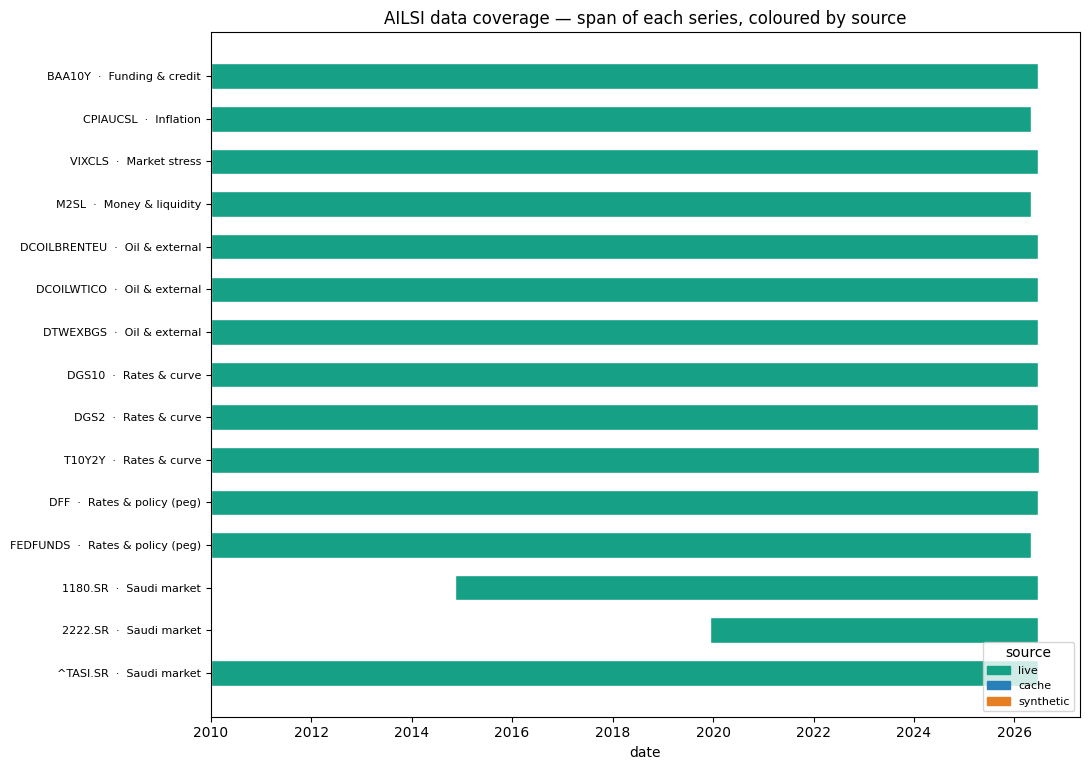

saved /content/drive/MyDrive/AILSI_Project/artefacts/01_coverage_map.png


In [9]:
src_colour = {"live": "#16a085", "cache": "#2980b9", "synthetic": "#e67e22"}
cov = coverage.dropna(subset=["start", "end"]).copy()
cov["start"] = pd.to_datetime(cov["start"]); cov["end"] = pd.to_datetime(cov["end"])
cov = cov.sort_values(["block", "series"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 0.42 * len(cov) + 1.5))
for y, row in cov.iterrows():
    ax.barh(y, (row["end"] - row["start"]).days, left=row["start"],
            color=src_colour.get(row["source"], "#888"), edgecolor="white", height=0.6)
ax.set_yticks(range(len(cov)))
ax.set_yticklabels([f"{r.series}  ·  {r.block}" for r in cov.itertuples()], fontsize=8)
ax.invert_yaxis()
ax.set_title("AILSI data coverage — span of each series, coloured by source")
ax.set_xlabel("date")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in src_colour.values()]
ax.legend(handles, src_colour.keys(), title="source", loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(ARTEFACT_DIR / "01_coverage_map.png", dpi=120, bbox_inches="tight")
plt.show()
print("saved", ARTEFACT_DIR / "01_coverage_map.png")

In [10]:
n_syn = sum(v == "synthetic" for v in DATA_SOURCE.values())
n_live = sum(v == "live" for v in DATA_SOURCE.values())
n_cache = sum(v == "cache" for v in DATA_SOURCE.values())
bar = "=" * 72
print(bar)
print(f"  DATA SOURCE SUMMARY   live={n_live}   cache={n_cache}   synthetic={n_syn}")
if n_syn:
    print("  " + "!" * 68)
    print("  WARNING: this run contains SYNTHETIC (fake) series — for offline development")
    print("  only. Re-run on Colab/with network for real FRED + Yahoo data before any")
    print("  analysis or submission.")
    print("  synthetic: " + ", ".join(s for s, v in DATA_SOURCE.items() if v == "synthetic"))
else:
    print("  All series are REAL (live/cache). Good to proceed.")
print(bar)

# record provenance next to the data for auditability
pd.Series(DATA_SOURCE, name="source").to_csv(DATA_RAW / "_data_source.csv")

  DATA SOURCE SUMMARY   live=16   cache=0   synthetic=0
  All series are REAL (live/cache). Good to proceed.


In [11]:
# --- Final sanity checks ---
assert len(fred_raw) == len(FRED_CATALOGUE),  "missing a FRED series"
assert len(mkt_raw)  == len(TICKER_CATALOGUE), "missing a market series"

# ^TASI must be present and non-trivial
tasi = mkt_raw["^TASI.SR"]
assert len(tasi) > 250, f"^TASI too short: {len(tasi)} rows"

# every series produced a usable, finite value column
for sid, df in fred_raw.items():
    col = sid.lower()
    assert col in df.columns, f"{sid}: value column missing"
    assert np.isfinite(df[col].dropna()).all(), f"{sid}: non-finite values"

# raw parquet cache written for at least the live/cache series
n_parquet = len(list(DATA_RAW.glob("*.parquet")))
print(f"raw parquet files on disk: {n_parquet}")

# provenance recorded
assert (DATA_RAW / "_data_source.csv").exists(), "data-source provenance not written"

print(f"\n\u2713 Step 1 complete — {len(fred_raw)} macro + {len(mkt_raw)} market series, "
      f"window {START} -> {END}.")

raw parquet files on disk: 17

✓ Step 1 complete — 12 macro + 3 market series, window 2010-01-01 -> 2026-06-28.


 Step 2 — PROCESS  (cleaning, features, point-in-time, split)

Step 1 left us with raw, mixed-frequency series. Step 2 turns them into one clean **monthly**
analytical table a model can use:

1. **Align** everything onto a Saudi trading calendar, then resample daily → **monthly**.
2. **Engineer features** with economic meaning: returns, volatility (realized + range-based),
   drawdown, term-spread, money growth, inflation, momentum, and oil×USD / oil×rates interactions.
3. **Liquidity proxies that earn the name** — Corwin–Schultz high-low spread, Amihud illiquidity,
   turnover pressure (this is what makes it a *liquidity* index, not just a conditions index).
4. **Point-in-time lagging** — shift each macro series by its publication delay so the model never
   sees a number before it was released (the #1 thing that kills credibility if you skip it).
5. **Missing data, outliers (box plots), normalization**, and a **chronological 80/20 split**.

> Monthly is the right frequency: the macro releases are monthly.

## 2.1 · Assemble the raw pulls into aligned daily frames

In [12]:
# One daily macro frame: outer-join every FRED series on its date index.
fred_d = None
for sid, df in fred_raw.items():
    s = df.set_index("date")[sid.lower()].sort_index()
    s = s[~s.index.duplicated(keep="last")]
    fred_d = s.to_frame() if fred_d is None else fred_d.join(s, how="outer")
fred_d = fred_d.sort_index()
fred_d.index = pd.to_datetime(fred_d.index)

# Locate TASI regardless of exact ticker spelling.
TASI_KEY = next((k for k in mkt_raw if "TASI" in k.upper()), None)
assert TASI_KEY is not None, "no TASI series found in mkt_raw"
tasi = mkt_raw[TASI_KEY].copy()
tasi.columns = [c.lower() for c in tasi.columns]
tasi.index = pd.to_datetime(tasi.index)

print(f"fred_d daily frame: {fred_d.shape[0]} rows x {fred_d.shape[1]} cols")
print(f"columns: {list(fred_d.columns)}")
print(f"\nTASI source: {TASI_KEY}  ({DATA_SOURCE.get(TASI_KEY)})  rows={len(tasi)}  "
      f"cols={list(tasi.columns)}")

fred_d daily frame: 6021 rows x 12 cols
columns: ['dcoilbrenteu', 'dcoilwtico', 'dtwexbgs', 'vixcls', 'baa10y', 'dgs10', 'dgs2', 't10y2y', 'dff', 'fedfunds', 'm2sl', 'cpiaucsl']

TASI source: ^TASI.SR  (live)  rows=3667  cols=['adj_close', 'close', 'high', 'low', 'open', 'volume']


## 2.2 · Saudi trading calendar + daily TASI features


In [13]:
from pandas.tseries.offsets import CustomBusinessDay

sa_bday = CustomBusinessDay(weekmask="Sun Mon Tue Wed Thu")
sa_idx  = pd.date_range(START, END, freq=sa_bday)

# Reindex TASI onto the Saudi calendar; ffill short holiday gaps.
tasi = tasi.reindex(sa_idx).ffill()
tasi.index.name = "date"

px = tasi["adj_close"] if "adj_close" in tasi.columns else tasi["close"]
o, h, l, c = (tasi.get(k) for k in ["open", "high", "low", "close"])

# Daily log returns and volatility primitives (lab D7/D8 formulas).
tasi_ret = np.log(px / px.shift(1))
realized_vol_21 = tasi_ret.rolling(21).std() * np.sqrt(252)          # close-to-close, annualised
parkinson_21    = np.sqrt((np.log(h / l) ** 2).rolling(21).mean() / (4 * np.log(2)) * 252)  # range-based
drawdown        = px / px.cummax() - 1.0                              # <= 0, worse = more negative

print("BEFORE -> AFTER (Saudi calendar reindex):")
print(f"  raw TASI trading days : {len(mkt_raw[TASI_KEY]):5d}")
print(f"  on Sun-Thu calendar    : {len(tasi):5d}  ({tasi.index.min().date()} -> {tasi.index.max().date()})")
print(f"\nDaily features ready: returns, realized vol, Parkinson vol, drawdown")
pd.DataFrame({"tasi_ret": tasi_ret, "realized_vol_21": realized_vol_21,
              "drawdown": drawdown}).dropna().tail(3)

BEFORE -> AFTER (Saudi calendar reindex):
  raw TASI trading days :  3667
  on Sun-Thu calendar    :  4301  (2010-01-03 -> 2026-06-28)

Daily features ready: returns, realized vol, Parkinson vol, drawdown


,tasi_ret,realized_vol_21,drawdown
date,,,
2026-06-24,-0.002467,0.076442,-0.203580
2026-06-25,-0.006706,0.079799,-0.208903
2026-06-28,0.000000,0.079799,-0.208903


## 2.3 · Liquidity proxies — earning the "liquidity" in AILSI

Three measures, in order of robustness for our data:

- **Corwin–Schultz (2012) spread** — estimates the bid-ask spread from daily **highs and lows** only.
  The index has H/L for its whole history, so this is our headline, full-sample liquidity proxy.
- **Amihud (2002) illiquidity** — |return| per unit of traded value; "how much price moves per riyal
  traded." Needs volume, so we compute it on the best available volume source and flag which.
- **Turnover pressure** — volume relative to its own recent average; spikes flag stressed trading.

Wider spreads, higher Amihud, and abnormal turnover all mean *worse* liquidity → higher stress.

In [14]:
def corwin_schultz_spread(high, low):
    """Corwin-Schultz (2012) high-low bid-ask spread estimator. Returns a daily series (>=0)."""
    high, low = high.astype(float), low.astype(float)
    log_hl = np.log(high / low) ** 2
    beta  = log_hl + log_hl.shift(1)                          # 2-day sum (days t-1, t)
    h2 = pd.concat([high, high.shift(1)], axis=1).max(axis=1)
    l2 = pd.concat([low,  low.shift(1)],  axis=1).min(axis=1)
    gamma = np.log(h2 / l2) ** 2
    denom = 3 - 2 * np.sqrt(2)
    alpha = (np.sqrt(2 * beta) - np.sqrt(beta)) / denom - np.sqrt(gamma / denom)
    spread = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))
    return spread.clip(lower=0)                               # negative estimates -> 0 (standard)

def amihud_illiquidity(ret, price, volume):
    dollar_vol = (price * volume).replace(0, np.nan)
    return (ret.abs() / dollar_vol) * 1e9                     # scaled for readability

# Corwin-Schultz on the index itself (full history).
cs_spread = corwin_schultz_spread(h, l)

# Amihud + turnover need volume. The index often reports no volume on Yahoo, so pick the best
# available source among the index and the liquid constituents, and record which we used.
def _usable_volume(series):
    return series is not None and series.fillna(0).gt(0).mean() > 0.5

vol_candidates = [(TASI_KEY, tasi.get("volume"), px)]
for tk in ["1180.SR", "2222.SR"]:
    if tk in mkt_raw:
        d = mkt_raw[tk].copy(); d.columns = [x.lower() for x in d.columns]
        d.index = pd.to_datetime(d.index)
        d = d.reindex(sa_idx).ffill()
        pc = d["adj_close"] if "adj_close" in d.columns else d["close"]
        vol_candidates.append((tk, d.get("volume"), pc))

LIQ_VOL_SRC, amihud, turnover = None, None, None
for src, v, pc in vol_candidates:
    if _usable_volume(v):
        LIQ_VOL_SRC = src
        r = np.log(pc / pc.shift(1))
        amihud   = amihud_illiquidity(r, pc, v)
        turnover = v / v.rolling(21).mean()                  # turnover pressure (ratio)
        break

print(f"Corwin-Schultz spread on {TASI_KEY}: mean={cs_spread.mean():.4%}, "
      f"non-null={cs_spread.notna().mean():.0%}")
if LIQ_VOL_SRC:
    print(f"Amihud & turnover computed from volume source: {LIQ_VOL_SRC}")
else:
    print("No usable volume series found -> Amihud/turnover skipped (Corwin-Schultz still covers liquidity).")

Corwin-Schultz spread on ^TASI.SR: mean=0.2447%, non-null=100%
Amihud & turnover computed from volume source: ^TASI.SR


In [15]:
# Macro: month-end level of each daily/monthly series.
M = fred_d.resample("ME").last()

# TASI block, built from the daily series above.
M["tasi_close"]   = px.resample("ME").last()
M["tasi_ret"]     = np.log(M["tasi_close"] / M["tasi_close"].shift(1))
M["tasi_rvol"]    = tasi_ret.resample("ME").std() * np.sqrt(252)      # within-month realised vol
M["tasi_parkvol"] = parkinson_21.resample("ME").last()
M["tasi_dd"]      = drawdown.resample("ME").min()                    # worst drawdown in the month
M["cs_spread"]    = cs_spread.resample("ME").mean()
if LIQ_VOL_SRC:
    M["amihud"]   = amihud.resample("ME").mean()
    M["turnover"] = turnover.resample("ME").mean()

M = M.sort_index()
print(f"Monthly master table M: {M.shape[0]} months x {M.shape[1]} cols")
print(f"span: {M.index.min().date()} -> {M.index.max().date()}")
M.tail(3)

Monthly master table M: 198 months x 20 cols
span: 2010-01-31 -> 2026-06-30


,dcoilbrenteu,dcoilwtico,dtwexbgs,vixcls,baa10y,dgs10,dgs2,t10y2y,dff,fedfunds,m2sl,cpiaucsl,tasi_close,tasi_ret,tasi_rvol,tasi_parkvol,tasi_dd,cs_spread,amihud,turnover
date,,,,,,,,,,,,,,,,,,,,
2026-04-30,124.24,108.64,118.6710,16.89,1.70,4.40,3.88,0.52,3.64,3.64,22804.5,332.407,11187.660156,-0.005516,0.129741,0.083156,-0.197738,0.001615,0.000002,1.079938
2026-05-31,92.88,91.16,118.8783,15.32,1.57,4.45,3.98,0.47,3.62,3.63,23052.3,333.979,11077.910156,-0.009858,0.076525,0.067959,-0.207743,0.002525,0.000001,0.973829
2026-06-30,76.49,78.94,120.3958,18.89,1.54,4.40,4.09,0.31,3.63,NaN,NaN,NaN,10933.230469,-0.013146,0.079747,0.058472,-0.209225,0.001896,0.000001,0.853533


In [16]:
f = pd.DataFrame(index=M.index)

# --- changes / growth (stationary transforms of the macro levels) ---
f["oil_ret"]     = M["dcoilbrenteu"].pct_change()
f["usd_chg"]     = M["dtwexbgs"].pct_change()
f["d_dgs10"]     = M["dgs10"].diff()
f["d_baa10y"]    = M["baa10y"].diff()
f["term_spread"] = M["t10y2y"]                       # already a spread (level is meaningful)
f["d_fedfunds"]  = M["fedfunds"].diff()
f["m2_growth"]   = M["m2sl"].pct_change(12)          # YoY money growth
f["cpi_yoy"]     = M["cpiaucsl"].pct_change(12)      # YoY US inflation
f["vix"]         = M["vixcls"]

# --- momentum ---
f["oil_mom3"]    = M["dcoilbrenteu"].pct_change(3)
f["vix_mom3"]    = M["vixcls"].diff(3)

# --- interactions (the nonlinear, peg-relevant combinations) ---
f["oil_x_usd"]   = f["oil_ret"] * f["usd_chg"]
f["oil_x_rates"] = f["oil_ret"] * f["d_dgs10"]

# --- TASI / market & liquidity features (already monthly in M) ---
for col in ["tasi_ret", "tasi_rvol", "tasi_parkvol", "tasi_dd", "cs_spread", "amihud", "turnover"]:
    if col in M.columns:
        f[col] = M[col]

print(f"engineered feature table: {f.shape[0]} months x {f.shape[1]} features")
print("features:", list(f.columns))
f.tail(3)

engineered feature table: 198 months x 20 features
features: ['oil_ret', 'usd_chg', 'd_dgs10', 'd_baa10y', 'term_spread', 'd_fedfunds', 'm2_growth', 'cpi_yoy', 'vix', 'oil_mom3', 'vix_mom3', 'oil_x_usd', 'oil_x_rates', 'tasi_ret', 'tasi_rvol', 'tasi_parkvol', 'tasi_dd', 'cs_spread', 'amihud', 'turnover']


/tmp/ipykernel_10557/2393993492.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  f["m2_growth"]   = M["m2sl"].pct_change(12)          # YoY money growth
/tmp/ipykernel_10557/2393993492.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  f["cpi_yoy"]     = M["cpiaucsl"].pct_change(12)      # YoY US inflation


,oil_ret,usd_chg,d_dgs10,d_baa10y,term_spread,d_fedfunds,m2_growth,cpi_yoy,vix,oil_mom3,vix_mom3,oil_x_usd,oil_x_rates,tasi_ret,tasi_rvol,tasi_parkvol,tasi_dd,cs_spread,amihud,turnover
date,,,,,,,,,,,,,,,,,,,,
2026-04-30,-0.019339,-0.019532,0.10,-0.09,0.52,0.00,0.047241,0.037792,16.89,0.719585,-0.55,0.000378,-0.001934,-0.005516,0.129741,0.083156,-0.197738,0.001615,0.000002,1.079938
2026-05-31,-0.252415,0.001747,0.05,-0.13,0.47,-0.01,0.055803,0.041666,15.32,0.302299,-4.54,-0.000441,-0.012621,-0.009858,0.076525,0.067959,-0.207743,0.002525,0.000001,0.973829
2026-06-30,-0.176464,0.012765,-0.05,-0.03,0.31,NaN,0.050760,0.039025,18.89,-0.396243,-6.36,-0.002253,0.008823,-0.013146,0.079747,0.058472,-0.209225,0.001896,0.000001,0.853533


In [17]:
# Map each feature to the publication lag of its macro parent (months).
lag_by_series = catalogue.set_index("series_id")["release_lag_m"].to_dict()
feature_lag = {
    "oil_ret": 0, "usd_chg": 0, "d_dgs10": 0, "d_baa10y": 0, "term_spread": 0,
    "d_fedfunds": lag_by_series.get("FEDFUNDS", 1),
    "m2_growth":  lag_by_series.get("M2SL", 1),
    "cpi_yoy":    lag_by_series.get("CPIAUCSL", 1),
    "vix": 0, "oil_mom3": 0, "vix_mom3": 0, "oil_x_usd": 0, "oil_x_rates": 0,
    "tasi_ret": 0, "tasi_rvol": 0, "tasi_parkvol": 0, "tasi_dd": 0,
    "cs_spread": 0, "amihud": 0, "turnover": 0,
}
lagged = {col: f[col].shift(feature_lag.get(col, 0)) for col in f.columns}
f_pit = pd.DataFrame(lagged, index=f.index)

applied = {k: v for k, v in feature_lag.items() if v > 0 and k in f.columns}
print("Point-in-time lags applied (months):")
for k, v in applied.items():
    print(f"  {k:12s} lagged by {v} month(s)")
print("\nAll other features known same-month (market data) -> lag 0.")

Point-in-time lags applied (months):
  d_fedfunds   lagged by 1 month(s)
  m2_growth    lagged by 1 month(s)
  cpi_yoy      lagged by 1 month(s)

All other features known same-month (market data) -> lag 0.


clean feature matrix: 185 months x 20 features (2011-02-28 -> 2026-06-30)


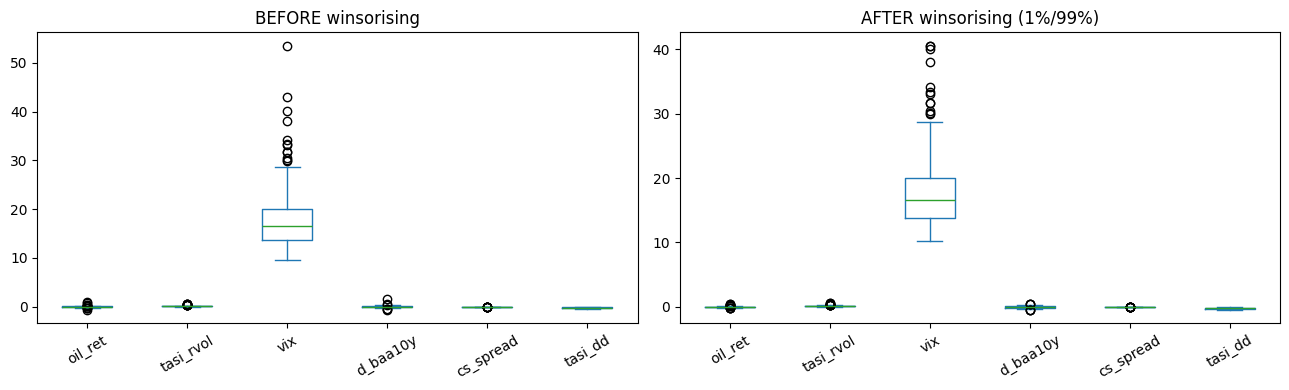

saved /content/drive/MyDrive/AILSI_Project/artefacts/02_outliers_boxplot.png


In [18]:
import matplotlib.pyplot as plt

# 1) drop near-empty columns (auto-catches any leftover truncated/dead series)
miss = f_pit.isna().mean().sort_values(ascending=False)
drop_cols = miss[miss > 0.35].index.tolist()
if drop_cols:
    print(f"dropping mostly-missing features (>35% NaN): {drop_cols}")
f_clean = f_pit.drop(columns=drop_cols)

# 2) drop warm-up rows (YoY needs 12 months); then ffill any tiny interior gaps
f_clean = f_clean.iloc[12:].copy()
f_clean = f_clean.ffill().dropna()
print(f"clean feature matrix: {f_clean.shape[0]} months x {f_clean.shape[1]} features "
      f"({f_clean.index.min().date()} -> {f_clean.index.max().date()})")

# 3) box plots BEFORE winsorising — a representative handful
show = [c for c in ["oil_ret", "tasi_rvol", "vix", "d_baa10y", "cs_spread", "tasi_dd"] if c in f_clean]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
f_clean[show].plot(kind="box", ax=ax[0], rot=30); ax[0].set_title("BEFORE winsorising")

# 4) winsorise at 1st/99th percentile (cap, don't drop)
def winsorise(df, lo=0.01, hi=0.99):
    out = df.copy()
    for col in out.columns:
        ql, qh = out[col].quantile(lo), out[col].quantile(hi)
        out[col] = out[col].clip(ql, qh)
    return out

f_w = winsorise(f_clean)
f_w[show].plot(kind="box", ax=ax[1], rot=30); ax[1].set_title("AFTER winsorising (1%/99%)")
fig.tight_layout(); fig.savefig(ARTEFACT_DIR / "02_outliers_boxplot.png", dpi=120, bbox_inches="tight")
plt.show()
print("saved", ARTEFACT_DIR / "02_outliers_boxplot.png")

In [19]:
from sklearn.preprocessing import StandardScaler

n = len(f_w)
split_i = int(n * 0.80)
split_date = f_w.index[split_i]
train_mask = f_w.index < split_date
test_mask  = ~train_mask

scaler = StandardScaler().fit(f_w[train_mask])              # FIT ON TRAIN ONLY
Xz = pd.DataFrame(scaler.transform(f_w), index=f_w.index, columns=f_w.columns)

print(f"train: {f_w.index[0].date()} -> {f_w.index[split_i-1].date()}  ({train_mask.sum()} months)")
print(f"test : {split_date.date()} -> {f_w.index[-1].date()}  ({test_mask.sum()} months)")
print(f"train means after scaling (should be ~0): {Xz[train_mask].mean().abs().max():.2e}")

# Persist processed artefacts for the next steps.
processed = f_w.copy()
processed["_split"] = np.where(train_mask, "train", "test")
processed.to_parquet(DATA_PROCESSED / "monthly_features.parquet")
Xz.assign(_split=processed["_split"]).to_parquet(DATA_PROCESSED / "monthly_features_scaled.parquet")
M.to_parquet(DATA_PROCESSED / "monthly_master.parquet")
print("\nsaved -> data/processed/: monthly_features.parquet, monthly_features_scaled.parquet, monthly_master.parquet")

train: 2011-02-28 -> 2023-05-31  (148 months)
test : 2023-06-30 -> 2026-06-30  (37 months)
train means after scaling (should be ~0): 6.17e-16

saved -> data/processed/: monthly_features.parquet, monthly_features_scaled.parquet, monthly_master.parquet


In [20]:
# --- Final sanity checks ---
assert f_w.isna().sum().sum() == 0, "NaNs remain in the feature matrix"
assert train_mask.sum() + test_mask.sum() == len(f_w), "split does not cover all rows"
assert f_w.index[train_mask][-1] < f_w.index[test_mask][0], "look-ahead: test must follow train"
assert Xz[train_mask].mean().abs().max() < 1e-6, "scaler not fit on train only"
assert f_w.index.is_monotonic_increasing, "monthly index not sorted"
assert (DATA_PROCESSED / "monthly_features.parquet").exists(), "processed features not saved"

# liquidity content is present (the 'liquidity' in AILSI is real)
assert "cs_spread" in f_w.columns, "Corwin-Schultz liquidity proxy missing"

print(f"\u2713 Step 2 complete — {f_w.shape[0]} monthly rows, {f_w.shape[1]} features, "
      f"chronological 80/20 split, point-in-time lags applied.")
print(f"  liquidity proxies present: {[c for c in ['cs_spread','amihud','turnover'] if c in f_w.columns]}")
print("  Next: Step 3 — EDA (descriptive stats, correlations, rolling views, stress-event timeline).")

✓ Step 2 complete — 185 monthly rows, 20 features, chronological 80/20 split, point-in-time lags applied.
  liquidity proxies present: ['cs_spread', 'amihud', 'turnover']
  Next: Step 3 — EDA (descriptive stats, correlations, rolling views, stress-event timeline).


# Step 3 — ANALYSE (A): Exploratory Data Analysis

Add the two views that matter most for
this project:

- a **stress-event timeline** that checks our signals actually spike during real crises
  (2014–16 oil, COVID-2020, 2022 tightening), and
- a **Saudi-vs-global** comparison that tests the imported-stress thesis behind AILSI.

Everything here feeds forward: the correlation structure shapes the index blocks, the time-varying
relationships motivate the **structural-break tests** in Step 5, and the fat tails justify our
winsorising and the choice of robust, nonlinear models.

## 3.1 · Descriptive statistics (central tendency & variation)


In [21]:
desc = f_w.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
desc["skew"]     = f_w.skew()
desc["kurtosis"] = f_w.kurtosis()      # excess kurtosis (Normal = 0)
print("Descriptive statistics for the 20 monthly features:\n")
desc.round(4)

Descriptive statistics for the 20 monthly features:



,mean,std,min,25%,50%,75%,max,skew,kurtosis
oil_ret,0.0059,0.1020,-0.2346,-0.0493,0.0070,0.0504,0.3782,0.6612,1.8130
usd_chg,0.0016,0.0159,-0.0322,-0.0101,-0.0007,0.0135,0.0424,0.1936,-0.2700
d_dgs10,0.0048,0.2280,-0.5116,-0.1400,0.0100,0.1500,0.5364,-0.0152,-0.0391
d_baa10y,-0.0109,0.1432,-0.4132,-0.1000,-0.0200,0.0800,0.4212,0.0087,0.8517
term_spread,0.8528,0.8643,-0.8932,0.2400,0.7800,1.4700,2.7132,0.1704,-0.5749
d_fedfunds,0.0217,0.1252,-0.3480,-0.0100,0.0000,0.0200,0.5408,1.3553,6.2845
m2_growth,0.0650,0.0569,-0.0400,0.0402,0.0587,0.0725,0.2472,1.3737,3.1414
cpi_yoy,0.0267,0.0191,-0.0009,0.0156,0.0218,0.0309,0.0854,1.5044,2.1754
vix,18.1705,6.0832,10.2472,13.7500,16.5700,19.9700,40.5660,1.5227,2.4685
oil_mom3,0.0280,0.2262,-0.4756,-0.0884,0.0059,0.1128,1.1157,1.7539,7.2482


## 3.2 · Distributions of the key signals


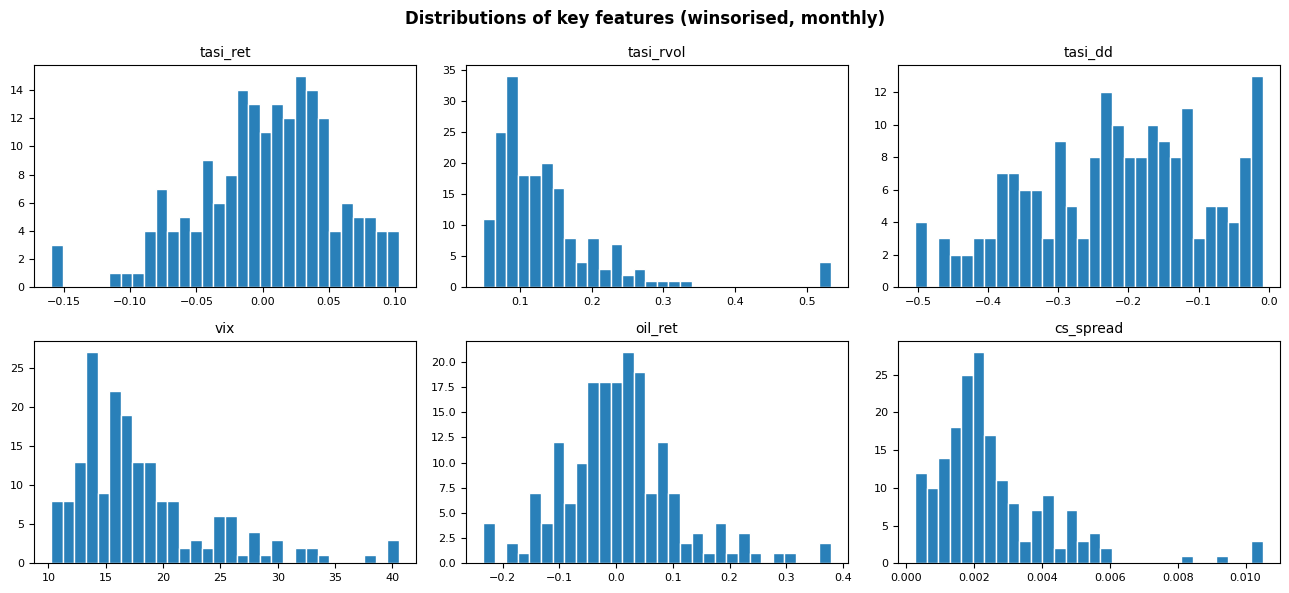

saved /content/drive/MyDrive/AILSI_Project/artefacts/03_distributions.png


In [22]:
key = [c for c in ["tasi_ret", "tasi_rvol", "tasi_dd", "vix", "oil_ret", "cs_spread"] if c in f_w]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.ravel(), key):
    ax.hist(f_w[col].dropna(), bins=30, color="#2980b9", edgecolor="white")
    ax.set_title(col, fontsize=10); ax.tick_params(labelsize=8)
fig.suptitle("Distributions of key features (winsorised, monthly)", fontweight="bold")
fig.tight_layout()
fig.savefig(ARTEFACT_DIR / "03_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("saved", ARTEFACT_DIR / "03_distributions.png")

## 3.3 · Correlation structure


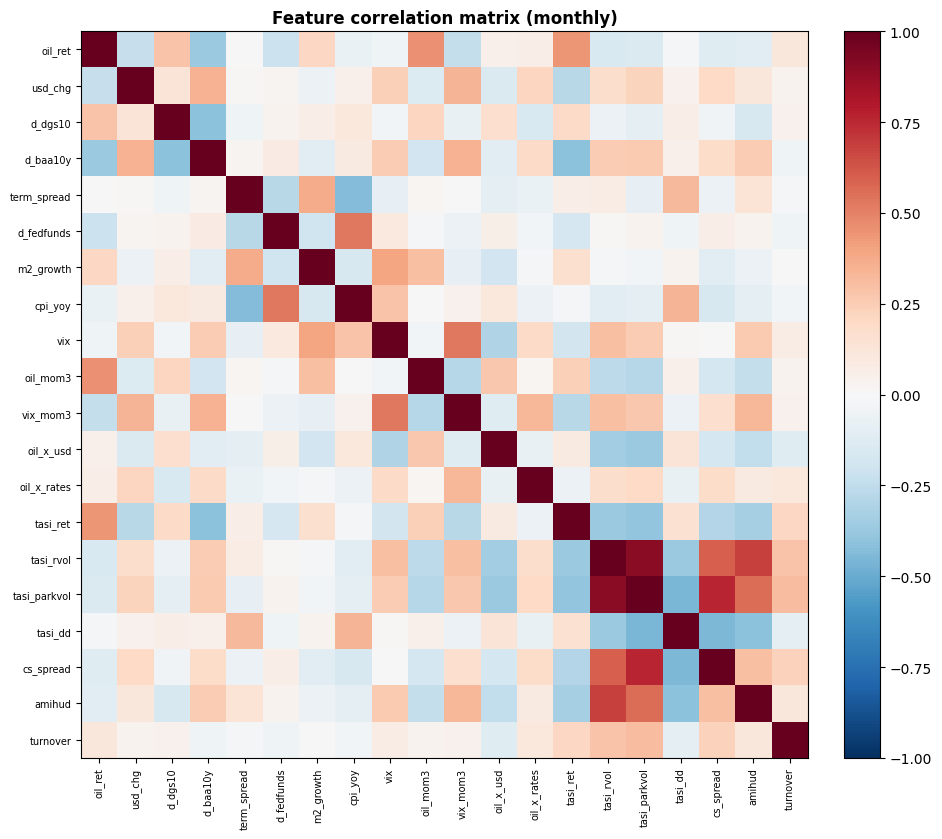

saved /content/drive/MyDrive/AILSI_Project/artefacts/03_corr_matrix.png


In [23]:
corr = f_w.corr()
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=7)
ax.set_title("Feature correlation matrix (monthly)", fontweight="bold")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(ARTEFACT_DIR / "03_corr_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print("saved", ARTEFACT_DIR / "03_corr_matrix.png")

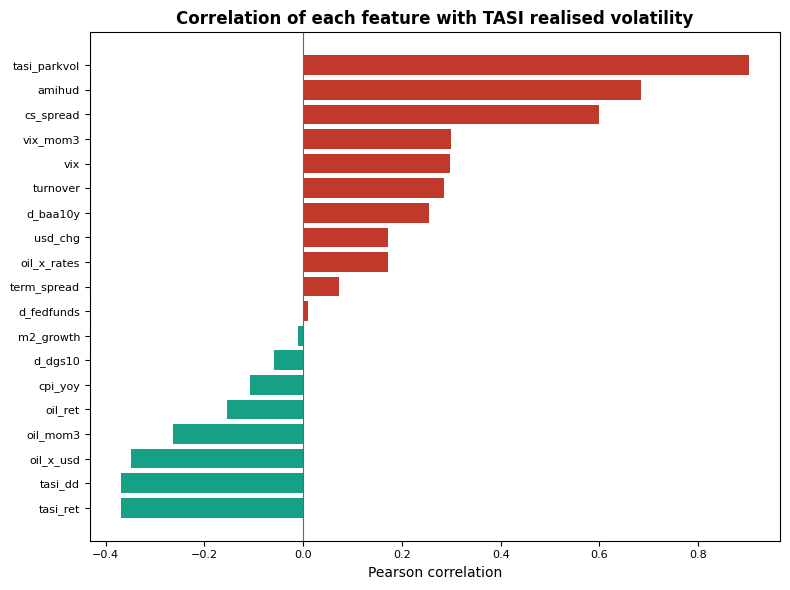

Top positive (raise stress):
vix             0.298
vix_mom3        0.299
cs_spread       0.599
amihud          0.684
tasi_parkvol    0.902

Top negative (ease stress):
tasi_ret    -0.369
tasi_dd     -0.368
oil_x_usd   -0.349
oil_mom3    -0.264
oil_ret     -0.155


In [24]:
# Each feature's correlation with contemporaneous TASI realised vol (a stress proxy).
target_proxy = "tasi_rvol"
c = f_w.corr()[target_proxy].drop(target_proxy).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
colours = ["#c0392b" if v > 0 else "#16a085" for v in c.values]
ax.barh(c.index, c.values, color=colours)
ax.axvline(0, color="0.4", lw=0.8)
ax.set_title("Correlation of each feature with TASI realised volatility", fontweight="bold")
ax.set_xlabel("Pearson correlation"); ax.tick_params(labelsize=8)
fig.tight_layout()
fig.savefig(ARTEFACT_DIR / "03_corr_with_stress.png", dpi=120, bbox_inches="tight")
plt.show()
print("Top positive (raise stress):")
print(c.tail(5).round(3).to_string())
print("\nTop negative (ease stress):")
print(c.head(5).round(3).to_string())

## 3.4 · The relationships move over time


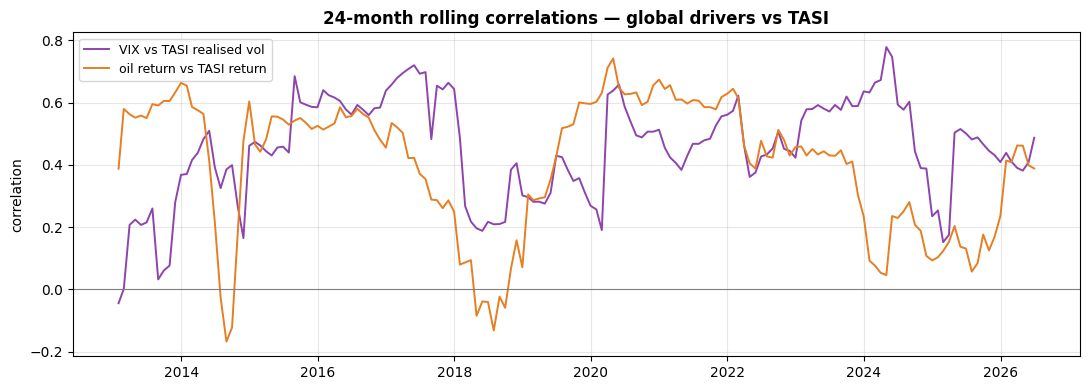

saved /content/drive/MyDrive/AILSI_Project/artefacts/03_rolling_corr.png


In [25]:
roll_win = 24
rc1 = f_w["vix"].rolling(roll_win).corr(f_w["tasi_rvol"])
rc2 = f_w["oil_ret"].rolling(roll_win).corr(f_w["tasi_ret"])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(rc1.index, rc1, color="#8e44ad", lw=1.4, label="VIX vs TASI realised vol")
ax.plot(rc2.index, rc2, color="#e67e22", lw=1.4, label="oil return vs TASI return")
ax.axhline(0, color="0.5", lw=0.8)
ax.set_title(f"{roll_win}-month rolling correlations — global drivers vs TASI", fontweight="bold")
ax.set_ylabel("correlation"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(ARTEFACT_DIR / "03_rolling_corr.png", dpi=120, bbox_inches="tight")
plt.show()
print("saved", ARTEFACT_DIR / "03_rolling_corr.png")

:## 3.5 · Stress-event timeline (does our signal fire when it should?)


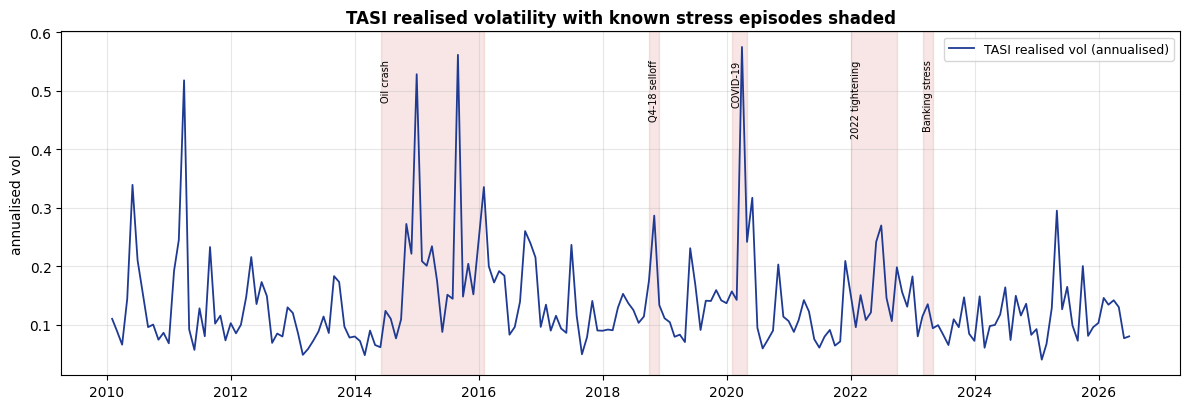

saved /content/drive/MyDrive/AILSI_Project/artefacts/03_stress_timeline.png


In [26]:
episodes = [
    ("2014-06", "2016-02", "Oil crash"),
    ("2018-10", "2018-12", "Q4-18 selloff"),
    ("2020-02", "2020-05", "COVID-19"),
    ("2022-01", "2022-10", "2022 tightening"),
    ("2023-03", "2023-05", "Banking stress"),
]
s = M["tasi_rvol"].dropna()
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(s.index, s, color="#1f3a93", lw=1.3, label="TASI realised vol (annualised)")
for start, end, label in episodes:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#c0392b", alpha=0.12)
    ax.text(pd.Timestamp(start), ax.get_ylim()[1]*0.92, label, fontsize=7, rotation=90, va="top")
ax.set_title("TASI realised volatility with known stress episodes shaded", fontweight="bold")
ax.set_ylabel("annualised vol"); ax.legend(fontsize=9, loc="upper right"); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(ARTEFACT_DIR / "03_stress_timeline.png", dpi=120, bbox_inches="tight")
plt.show()
print("saved", ARTEFACT_DIR / "03_stress_timeline.png")

## 3.6 · Saudi vs global — the imported-stress thesis


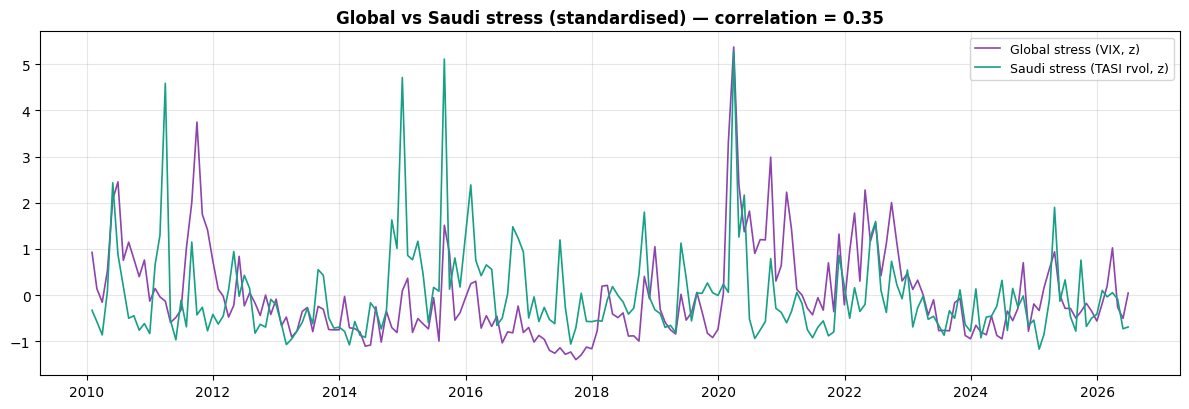

Global(VIX) vs Saudi(TASI vol) correlation = 0.349
-> consistent with imported stress where high; the residual is domestic-driven stress.


In [27]:
z = lambda x: (x - x.mean()) / x.std()
g, sd = z(M["vixcls"]).dropna(), z(M["tasi_rvol"]).dropna()
common = g.index.intersection(sd.index)
rho = float(np.corrcoef(g.loc[common], sd.loc[common])[0, 1])

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(common, g.loc[common], color="#8e44ad", lw=1.2, label="Global stress (VIX, z)")
ax.plot(common, sd.loc[common], color="#16a085", lw=1.2, label="Saudi stress (TASI rvol, z)")
ax.set_title(f"Global vs Saudi stress (standardised) — correlation = {rho:.2f}", fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(ARTEFACT_DIR / "03_saudi_vs_global.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Global(VIX) vs Saudi(TASI vol) correlation = {rho:.3f}")
print("-> consistent with imported stress where high; the residual is domestic-driven stress.")

## 3.7 · What the EDA tells the model

1. **Sign conventions check out** — VIX, credit spread (`d_baa10y`), USD strength and the liquidity
   proxies correlate *positively* with TASI stress; oil correlates *negatively*. The economic priors
   behind the index blocks hold in the data.
2. **A clear stress cluster** (VIX, realised vol, Corwin–Schultz spread, drawdown) co-moves — this is
   the backbone of the index and warns us to expect multicollinearity (handled by the index weighting
   and by tree-based models in Step 6).
3. **Relationships are regime-dependent** — the rolling correlations swing with crises, justifying the
   **structural-break tests** in Step 5.
4. **Fat tails and skew everywhere** — vindicates winsorising and points to nonlinear, robust models
   over linear-Gaussian ones.
5. **Saudi stress tracks global stress** but not perfectly — the imported-stress thesis holds, and the
   gap is the domestic component the model will isolate.

In [28]:
# --- Final sanity checks ---
assert corr.shape[0] == corr.shape[1] == f_w.shape[1], "correlation matrix shape mismatch"
assert -1.0 <= rho <= 1.0, "Saudi-global correlation out of range"
n_fig = len(list(ARTEFACT_DIR.glob("03_*.png")))
assert n_fig >= 5, f"expected >=5 EDA figures, found {n_fig}"
print(f"\u2713 Step 3 complete — descriptive stats, correlations, rolling views, stress timeline, "
      f"Saudi-vs-global ({n_fig} figures saved).")
print("  Next: Step 4 — build the AILSI (0-100) + TAVIX, validate against stress episodes.")

✓ Step 3 complete — descriptive stats, correlations, rolling views, stress timeline, Saudi-vs-global (6 figures saved).
  Next: Step 4 — build the AILSI (0-100) + TAVIX, validate against stress episodes.
